In [2]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'customer_id': [1, 2, 3],
        'purchase1': [100, 200, 150],
        'purchase2': [80, 120, 130]}
df = pd.DataFrame(data)

# 파생변수 생성: 총 구매액
df['total_purchase'] = df['purchase1'] + df['purchase2']
print(df)

   customer_id  purchase1  purchase2  total_purchase
0            1        100         80             180
1            2        200        120             320
2            3        150        130             280


In [ ]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'region': ['A', 'A', 'B', 'B', 'C'],
        'income': [5000, 6000, 5500, 6200, 5800]}
df = pd.DataFrame(data)

# 지역별 평균 소득 계산
avg_income = df.groupby('region')['income'].mean().reset_index()
avg_income.rename(columns={'income': 'avg_income'}, inplace=True)
print(avg_income)

In [ ]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'person': ['X', 'Y', 'Z'],
        'income': [4000, 5000, 6000]}
df = pd.DataFrame(data)

# 전체 평균 소득 계산
mean_income = df['income'].mean()

# 평균 대비 소득 차이 계산
df['income_diff'] = df['income'] - mean_income
print(df)

  person  income  income_diff
0      X    4000      -1000.0
1      Y    5000          0.0
2      Z    6000       1000.0


In [ ]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'region': ['A', 'B', 'C', 'D'],
        'avg_income': [5500, 5000, 6000, 4500]}
df = pd.DataFrame(data)

# 기준점 설정 (전체 평균 소득)
mean_income = df['avg_income'].mean()

# 소득 수준 분류
def categorize_income(x):
    if x > mean_income:
        return '높음'
    elif x == mean_income:
        return '보통'
    else:
        return '낮음'

df['income_level'] = df['avg_income'].apply(categorize_income)
print(df)

  region  avg_income income_level
0      A        5500           높음
1      B        5000           낮음
2      C        6000           높음
3      D        4500           낮음


In [ ]:
import pandas as pd
import numpy as np

data = {'name': ['Alice', 'Bob', 'Charlie', 'David'],
        'age': [25, np.nan, 30, np.nan]}
df = pd.DataFrame(data)

mean_age = df['age'].mean()

df['age'].fillna(mean_age, inplace=True)
print(df)

      name   age
0    Alice  25.0
1      Bob  27.5
2  Charlie  30.0
3    David  27.5


C:\Users\Playdata\AppData\Local\Temp\ipykernel_6188\196480052.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(mean_age, inplace=True)


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(30) # 랜덤의 일관성을 위해

# 예시 데이터프레임 생성
data = {'student': ['A', 'B', 'C', 'D', 'E'],
        'score': [80, np.nan, 90, np.nan, 85]}
df = pd.DataFrame(data)
nan_indices = df[df['score'].isnull()].index

df.loc[nan_indices, 'score'] = np.random.choice(df['score'].dropna(), size=len(nan_indices))
print(df)

  student  score
0       A   80.0
1       B   90.0
2       C   90.0
3       D   90.0
4       E   85.0


In [14]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 예시 데이터프레임 생성
data = {'feature1': [1.0, 2.1, np.nan, 4.3, 5.2],
        'feature2': [3.2, np.nan, 1.8, 2.5, 4.0]}
df = pd.DataFrame(data)
print(df)
# 다중대치법 적용
imputer = IterativeImputer(max_iter=10, random_state=0)
print(imputer)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print(df_imputed)

   feature1  feature2
0       1.0       3.2
1       2.1       NaN
2       NaN       1.8
3       4.3       2.5
4       5.2       4.0
IterativeImputer(random_state=0)
   feature1  feature2
0  1.000000  3.200000
1  2.100000  2.874009
2  3.148439  1.800000
3  4.300000  2.500000
4  5.200000  4.000000


In [15]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

# 사분위수 계산
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

# 이상값 기준 계산
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상값 식별
outliers = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]
print(outliers)

   value
5    100


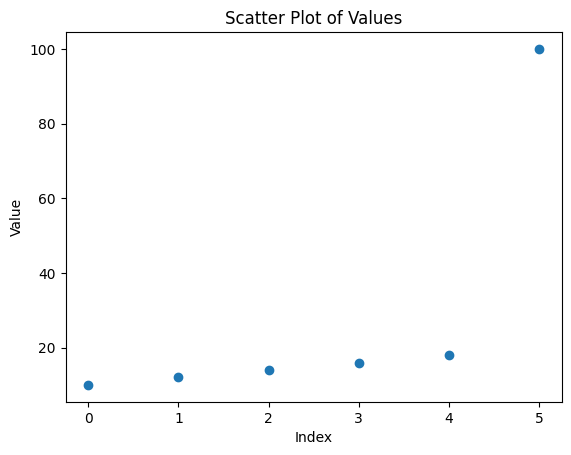

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

# 산점도 그리기
plt.scatter(df.index, df['value'])
plt.title('Scatter Plot of Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

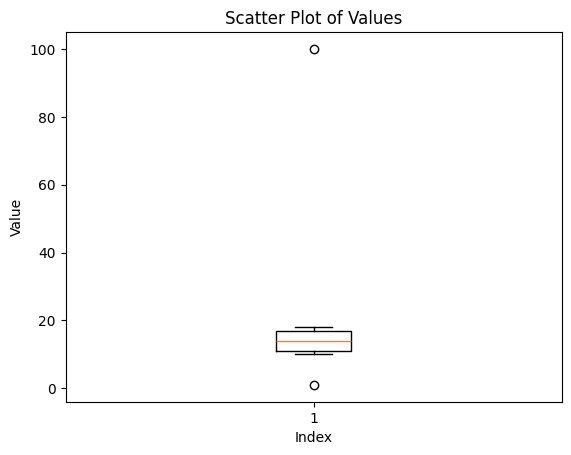

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터프레임 생성
data = {'value': [1, 10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

plt.boxplot(df["value"])

# 산점도 그리기
#plt.scatter(df.index, df['value'])
plt.title('Scatter Plot of Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [ ]:
import pandas as pd

data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

mean = df['score'].mean()
std = df['score'].std()

df['z_score'] = (df['score'] - mean) / std
df


,score,z_score
0,70,-1.264911
1,80,-0.632456
2,90,0.000000
3,100,0.632456
4,110,1.264911


In [21]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

max_val = df["score"].max()
min_val = df["score"].min()

df["zero_one"] = (df["score"] - min_val) / (max_val - min_val)
df

,score,zero_one
0,70,0.00
1,80,0.25
2,90,0.50
3,100,0.75
4,110,1.00


## 4-3. 중심극한정리

### 4-3-1. 중심극한정리란

<aside>
💡

중심극한정리는 표본의 크기가 충분히 크다면, 모수에 관계없이 표본평균의 분포가 정규분포에 가까워진다는 이론이다.

</aside>


E(\bar{X}) = \mu


Var(\bar{X}) = \frac{\sigma^2}{n}

- μ: 모평균
- σ2: 모분산
- n: 표본 크기

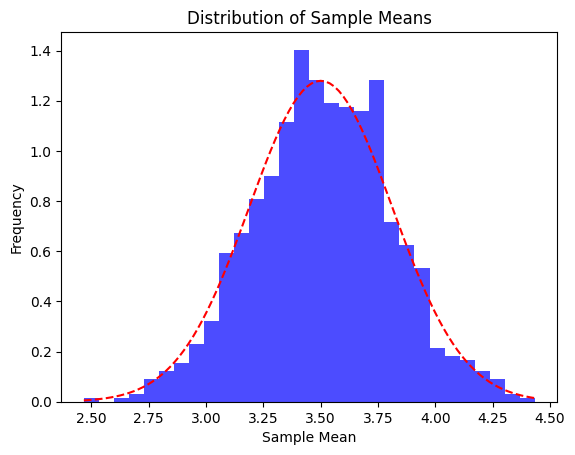

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 30
trials = 1000

sample_means = []

for _ in range(trials):
    samples = np.random.randint(1,7,n)
    sample_means.append(np.mean(samples))
    

plt.hist(sample_means, bins = 30, density=True, alpha=0.7, color='blue')
mu = 3.5  # 주사위 눈의 평균
sigma = np.sqrt(35/12) / np.sqrt(n)
x = np.linspace(min(sample_means), max(sample_means), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r--')

plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.show()

